In [2]:
import pandas as pd
import json
import seaborn as sns
import matplotlib.pyplot as plt

# Reading data

In [3]:
with open('data/v_3.json', 'r', encoding='utf-8') as file:
    raw_data = json.load(file)

# Extracting columns and data
columns = raw_data['columns']
data = raw_data['data']
df = pd.DataFrame(data, columns=columns)
print(df.head())

   Unnamed: 0       open_SAR  open_USD       high_SAR  high_USD  \
0  2021-01-30  128437.248512  34246.28  131012.723200  34933.00   
1  2021-01-29  125144.022272  33368.18  144510.037760  38531.90   
2  2021-01-28  113870.357376  30362.19  126703.438592  33783.98   
3  2021-01-27  121753.023104  32464.01  122102.860416  32557.29   
4  2021-01-26  120966.114176  32254.19  123470.218752  32921.88   

         low_SAR   low_USD      close_SAR  close_USD    volume  
0      123106.88  32825.00  128333.212416   34218.54   43072.0  
1   119695.51616  31915.40  128459.450880   34252.20  231827.0  
2   111919.81184  29842.10  125131.570944   33364.86   92621.0  
3  109668.146688  29241.72  113885.208960   30366.15   95911.0  
4  115652.472448  30837.37  121767.124608   32467.77   84972.0  


# Normalize data

In [4]:
print(df.isnull().sum())

# transforming columns to dtypes
df['open_SAR'] = pd.to_numeric(df['open_SAR'], errors='coerce')
df['open_USD'] = pd.to_numeric(df['open_USD'], errors='coerce')
df['high_SAR'] = pd.to_numeric(df['high_SAR'], errors='coerce')
df['high_USD'] = pd.to_numeric(df['high_USD'], errors='coerce')
df['low_SAR'] = pd.to_numeric(df['low_SAR'], errors='coerce')
df['low_USD'] = pd.to_numeric(df['low_USD'], errors='coerce')
df['close_SAR'] = pd.to_numeric(df['close_SAR'], errors='coerce')
df['close_USD'] = pd.to_numeric(df['close_USD'], errors='coerce')
df['volume'] = pd.to_numeric(df['volume'], errors='coerce')
df['date'] = pd.to_datetime(df['Unnamed: 0'], errors='coerce')

print(df.info())

Unnamed: 0    0
open_SAR      5
open_USD      4
high_SAR      4
high_USD      5
low_SAR       4
low_USD       4
close_SAR     4
close_USD     4
volume        6
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1012 entries, 0 to 1011
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Unnamed: 0  1012 non-null   object        
 1   open_SAR    1006 non-null   float64       
 2   open_USD    1008 non-null   float64       
 3   high_SAR    1008 non-null   float64       
 4   high_USD    1007 non-null   float64       
 5   low_SAR     1007 non-null   float64       
 6   low_USD     1008 non-null   float64       
 7   close_SAR   1008 non-null   float64       
 8   close_USD   1008 non-null   float64       
 9   volume      1006 non-null   float64       
 10  date        1012 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(9), object(1)
memory usage: 87.1+ KB
None


# Cleaning data

In [5]:
duplicates = df.duplicated(subset=['date'])
print(f"🔁 Found {duplicates.sum()} duplicate rows based on 'date'")
df = df[~duplicates]

🔁 Found 12 duplicate rows based on 'date'


# Filling data

📊 Basic Statistics:
            open_SAR      open_USD       high_SAR      high_USD  \
count    1000.000000   1000.000000    1000.000000   1000.000000   
mean    34835.382694   9295.020622   35826.894132   9542.457317   
min     12045.197184   3211.710000   12288.185600   3276.500000   
25%     24254.558752   6467.192500   24686.089152   6582.255000   
50%     30804.716736   8205.185000   31472.981760   8391.900000   
75%     38276.751168  10216.860000   39077.527200  10412.917500   
max    152217.334784  40586.960000  157329.280000  41950.000000   
std     21700.490347   5791.667933   22778.308677   6064.792605   

             low_SAR       low_USD      close_SAR      close_USD  \
count    1000.000000   1000.000000    1000.000000    1000.000000   
mean    33791.119542   9095.570234   34881.685693    9445.994207   
min     11837.237504   3156.260000    6723.350000    3211.720000   
25%     23717.904640   6325.015000   24214.504480    6466.762500   
50%     30031.384256   8011.505000  

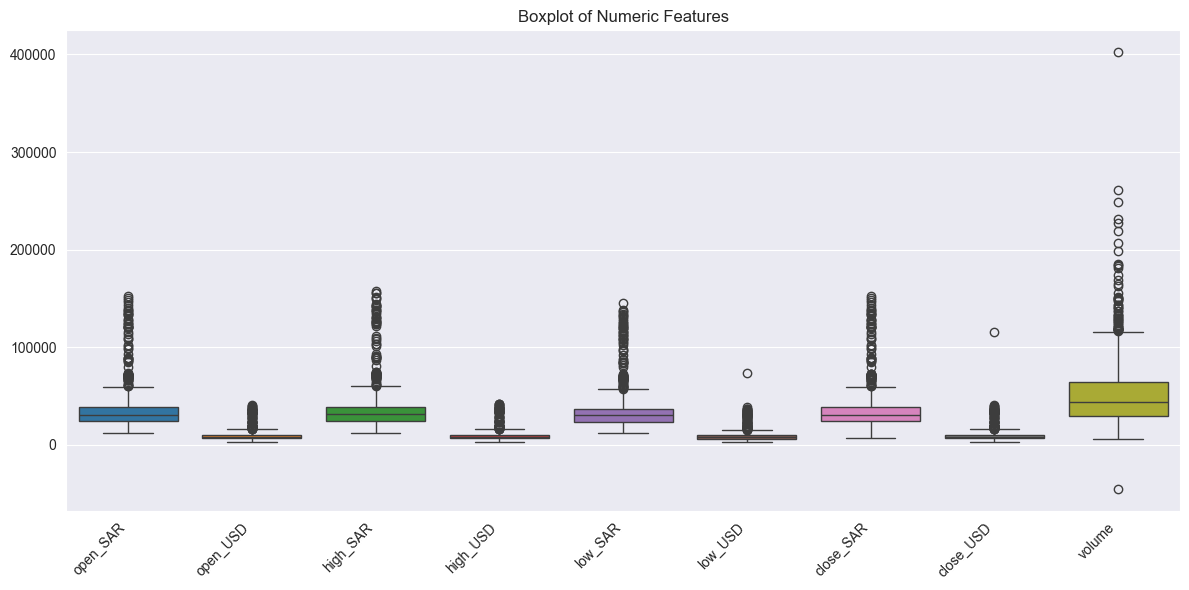

✅ Final Data Overview:
<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 1011
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Unnamed: 0  1000 non-null   object        
 1   open_SAR    1000 non-null   float64       
 2   open_USD    1000 non-null   float64       
 3   high_SAR    1000 non-null   float64       
 4   high_USD    1000 non-null   float64       
 5   low_SAR     1000 non-null   float64       
 6   low_USD     1000 non-null   float64       
 7   close_SAR   1000 non-null   float64       
 8   close_USD   1000 non-null   float64       
 9   volume      1000 non-null   float64       
 10  date        1000 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(9), object(1)
memory usage: 93.8+ KB
None


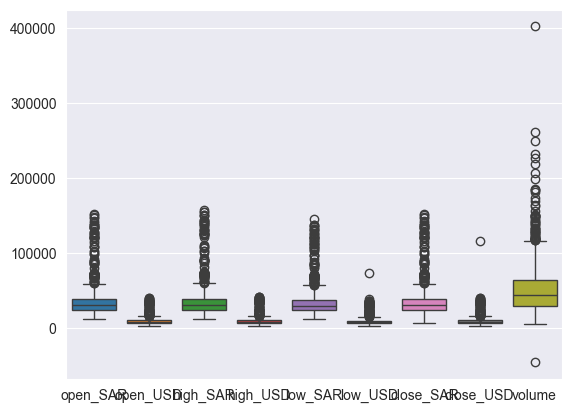

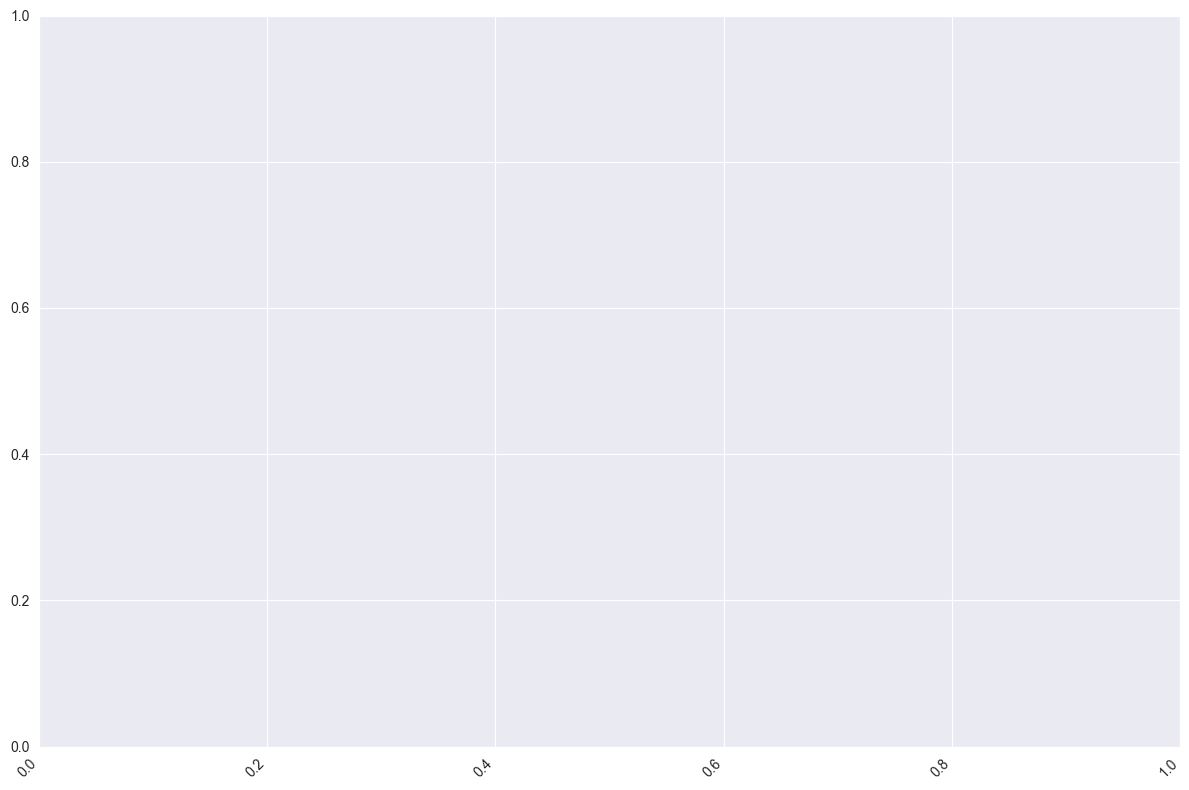

In [6]:
numeric_columns = df.select_dtypes(include=['number']).columns
df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].mean())

print("📊 Basic Statistics:")
print(df.describe())

plt.figure(figsize=(12, 6))
sns.boxplot(data=df[numeric_columns])
plt.xticks(rotation=45, ha='right')
plt.title("Boxplot of Numeric Features")
plt.tight_layout()
plt.show()

# data check after cleanuo
print("✅ Final Data Overview:")
print(df.info())
sns.boxplot(data=df)
plt.figure(figsize=(12, 8))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()